# Transformer 한영 번역기 — 정답지 기준 + 중요 코드 주석 완전판

이 노트북은 `translate.ipynb`의 구조에 맞추면서, 제출자가 코드의 목적을 설명할 수 있도록 **중요 코드마다 상세 주석**을 추가한 버전입니다.

핵심 기준은 다음과 같습니다.

| 항목 | 적용값 |
|---|---|
| Tokenizer | SentencePiece BPE |
| vocab size | 한국어 8000 / 영어 8000 |
| 최대 문장 길이 | 40 |
| 모델 구조 | Encoder 4층 + Decoder 4층 |
| d_model | 256 |
| n_heads | 8 |
| d_ff | 1024 |
| Loss | Label Smoothing Loss |
| Scheduler | Noam Learning Rate Scheduler |
| Padding 방식 | batch마다 동적 padding |
| Mask 기준 | `True = 가림`, `False = 볼 수 있음` |

## 학습목표 사전 체크

| 학습목표 | 이 노트북에서 확인하는 부분 |
|---|---|
| 텍스트 데이터 전처리 | 문장 정제, 중복 제거, SentencePiece 토큰화, 길이 필터링 |
| Transformer 내부 모듈 구현 | Positional Encoding, Multi-Head Attention, FFN, EncoderLayer, DecoderLayer |
| 모듈 조립 | EncoderLayer 여러 개 → Encoder, DecoderLayer 여러 개 → Decoder, 전체 Transformer 구성 |
| 학습 과정 설명 | optimizer, scheduler, label smoothing, train_step, gradient clipping |
| 번역 결과 확인 | 테스트 문장 출력, loss 그래프 출력, attention map 반환 준비 |

## 0. 기본 라이브러리 불러오기

전체 실습에 필요한 라이브러리를 불러오고, 실험 결과가 매번 크게 달라지지 않도록 seed를 고정합니다.  
GPU가 있으면 CUDA를 사용하고, 없으면 CPU를 사용합니다.

In [1]:
import os, re, math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# 실험 재현성을 위해 random seed를 고정합니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있는 경우 CUDA seed도 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 학습에 사용할 장치를 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)


torch: 2.7.1+cu118 | device: cuda


## 1. 데이터 다운로드 및 경로 설정

한영 병렬 말뭉치 파일이 이미 있으면 그대로 사용하고, 없으면 GitHub에서 다운로드합니다.  
정답지는 여러 실행 환경을 고려해 `~/work/transformer/data`, `/content`, 현재 폴더를 순서대로 확인합니다.

In [2]:
HOME = os.getenv("HOME")

# 데이터를 찾을 후보 폴더입니다.
candidate_dirs = [
    os.path.join(HOME, "work/transformer/data"),
    "/content",
    ".",
]

DATA_DIR = None

# 후보 폴더 중 실제 데이터가 있는 위치를 찾습니다.
for d in candidate_dirs:
    if os.path.exists(os.path.join(d, "korean-english-park.train.ko")):
        DATA_DIR = d
        break

# 데이터가 없으면 다운로드합니다.
if DATA_DIR is None:
    DATA_DIR = candidate_dirs[0]
    os.makedirs(DATA_DIR, exist_ok=True)
    url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/"
           "master/korean-english-news-v1/korean-english-park.train.tar.gz")
    os.system(f"wget -q {url} -P {DATA_DIR}")
    os.system(f"gzip -df {DATA_DIR}/korean-english-park.train.tar.gz")
    os.system(f"tar -xf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}")

KOR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.ko")
ENG_PATH = os.path.join(DATA_DIR, "korean-english-park.train.en")

print("DATA_DIR:", DATA_DIR)
print("kor:", os.path.exists(KOR_PATH), "eng:", os.path.exists(ENG_PATH))


DATA_DIR: /home/jovyan/work/transformer/data
kor: True eng: True


## 2. 문장 전처리 및 중복 제거

텍스트를 소문자로 통일하고, 문장부호를 분리하며, 불필요한 특수문자를 제거합니다.  
한국어와 영어 문장을 줄 번호 기준으로 묶고, 같은 문장쌍은 한 번만 남깁니다.

In [3]:
def preprocess_sentence(sentence: str) -> str:
    """문장을 토크나이저가 학습하기 쉬운 형태로 정리합니다."""
    # 대소문자 차이로 단어장이 불필요하게 커지는 것을 막습니다.
    sentence = sentence.lower().strip()

    # 문장부호 앞뒤에 공백을 넣어 독립 토큰으로 인식되게 합니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 영어, 한글, 기본 문장부호를 제외한 문자는 공백으로 바꿉니다.
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)

    # 여러 공백을 하나로 줄이고 앞뒤 공백을 제거합니다.
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


def load_pairs(kor_path, eng_path):
    """한국어/영어 병렬 파일을 읽고 중복 없는 문장쌍 리스트를 만듭니다."""
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()

    # 병렬 말뭉치는 한국어와 영어의 줄 수가 같아야 합니다.
    assert len(kor) == len(eng)

    seen, pairs = set(), []
    for k, e in zip(kor, eng):
        key = k + "\t" + e
        if key in seen:
            continue
        seen.add(key)
        pairs.append((preprocess_sentence(k), preprocess_sentence(e)))
    return pairs


pairs = load_pairs(KOR_PATH, ENG_PATH)
print(f"중복 제거 후 병렬쌍: {len(pairs):,}")
print("예시:", pairs[0])

kor_corpus = [k for k, _ in pairs]
eng_corpus = [e for _, e in pairs]


중복 제거 후 병렬쌍: 78,968
예시: ('개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?', 'much of personal computing is about can you top this ?')


## 3. SentencePiece 토크나이저 학습

정답지 기준으로 한국어와 영어 모두 `vocab_size=8000`을 사용합니다.  
영어 target에는 `bos:eos` 옵션을 적용해 시작 토큰과 종료 토큰을 자동으로 붙입니다.

In [4]:
try:
    import sentencepiece as spm
except ImportError:
    !pip install -q sentencepiece
    import sentencepiece as spm

SRC_VOCAB_SIZE = 8000
TGT_VOCAB_SIZE = 8000

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3


def generate_tokenizer(corpus, vocab_size, lang,
                       pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=UNK_ID):
    """SentencePiece 토크나이저를 학습하고 로드합니다."""
    txt_path = f"./{lang}_corpus.txt"
    model_prefix = f"./{lang}_spm"

    # 이전 실행에서 생성된 모델 파일이 있으면 삭제해 혼동을 방지합니다.
    for suffix in [".model", ".vocab"]:
        path = f"{model_prefix}{suffix}"
        if os.path.exists(path):
            os.remove(path)

    # SentencePiece 학습용 텍스트 파일을 저장합니다.
    with open(txt_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    # 정답지 기준: bpe, character_coverage=0.9995, vocab=8000
    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")
    return tokenizer


print("토크나이저 학습 중...")
ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# 영어 정답 문장에는 BOS/EOS가 자동으로 붙습니다.
en_tokenizer.set_encode_extra_options("bos:eos")

print("ko vocab:", ko_tokenizer.get_piece_size(), "en vocab:", en_tokenizer.get_piece_size())
print("샘플 인코딩:", en_tokenizer.encode_as_pieces("hello world"))


토크나이저 학습 중...


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=./ko_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ./ko_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_voca

ko vocab: 8000 en vocab: 8000
샘플 인코딩: ['<s>', '▁hel', 'lo', '▁world', '</s>']


178) LOG(INFO) Running command: --input=./en_corpus.txt --model_prefix=./en_spm --vocab_size=8000 --character_coverage=0.9995 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./en_corpus.txt
  input_format: 
  model_prefix: ./en_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_voca

## 4. 문장을 토큰 ID로 변환

정답지 기준으로 `MAX_LEN=40`을 사용합니다.  
여기서는 전체 데이터를 미리 하나의 큰 padding tensor로 만들지 않고, 문장별 tensor 리스트로 보관합니다. 이후 batch를 만들 때마다 동적으로 padding합니다.

In [5]:
MAX_LEN = 40

src_corpus, tgt_corpus = [], []

for k, e in zip(kor_corpus, eng_corpus):
    # 한국어 입력 문장을 token id로 변환합니다.
    s = ko_tokenizer.encode_as_ids(k)

    # 영어 정답 문장을 token id로 변환합니다. bos/eos가 포함됩니다.
    t = en_tokenizer.encode_as_ids(e)

    # 너무 긴 문장은 제외해 메모리와 학습 안정성을 확보합니다.
    if 1 <= len(s) <= MAX_LEN and 3 <= len(t) <= MAX_LEN:
        src_corpus.append(torch.tensor(s, dtype=torch.long))
        tgt_corpus.append(torch.tensor(t, dtype=torch.long))

print(f"학습용 병렬쌍: {len(src_corpus):,}")
print("src 예시 len:", len(src_corpus[0]), "tgt 예시 len:", len(tgt_corpus[0]))


학습용 병렬쌍: 58,876
src 예시 len: 16 tgt 예시 len: 15


## 5. 내부 모듈 구현하기 — 작은 부품부터 만들기

Transformer는 한 번에 만들지 않고, 아래 부품들을 순서대로 만든 뒤 조립합니다.

```text
Positional Encoding
→ Multi-Head Attention
→ Position-wise Feed Forward Network
→ EncoderLayer / DecoderLayer
→ Encoder / Decoder
→ Transformer 전체 모델
```

아래 코드들은 제출에서 설명이 필요한 핵심 코드이므로, 각 줄마다 왜 필요한지 주석을 달았습니다.

### 5-1. Positional Encoding

Transformer는 RNN처럼 단어를 순서대로 읽지 않습니다. 그래서 단어가 문장 안에서 몇 번째 위치에 있는지 알려주는 **위치 정보**가 필요합니다. 이 역할을 하는 것이 Positional Encoding입니다.

- 짝수 차원에는 `sin` 값을 넣습니다.
- 홀수 차원에는 `cos` 값을 넣습니다.
- 이렇게 하면 각 위치마다 고유한 숫자 패턴이 생깁니다.

In [6]:
def positional_encoding(pos_len, d_model):
    """
    sin/cos 기반 위치 인코딩을 생성하는 함수입니다.

    pos_len : 만들 위치 개수입니다. 예를 들어 MAX_LEN이 40이면 40개 이상의 위치 벡터가 필요합니다.
    d_model : 각 토큰 벡터의 차원입니다. 이 노트북에서는 256입니다.

    반환값 shape: [pos_len, d_model]
    """

    # 모든 위치와 모든 차원에 들어갈 값을 저장할 빈 배열을 만듭니다.
    # dtype을 float32로 지정하는 이유는 PyTorch 모델 파라미터와 자료형을 맞추기 위해서입니다.
    pe = np.zeros((pos_len, d_model), dtype=np.float32)

    # position은 단어의 위치 번호입니다.
    # shape을 [pos_len, 1]로 만들어야 뒤에서 차원별 div_term과 broadcasting 계산이 됩니다.
    position = np.arange(0, pos_len)[:, None]

    # div_term은 sin/cos 주기를 다르게 만들기 위한 값입니다.
    # 낮은 차원과 높은 차원이 서로 다른 주기 패턴을 갖게 만들어 위치를 더 잘 구분합니다.
    div_term = np.exp(np.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))

    # 짝수 번째 차원에는 sin 값을 넣습니다.
    pe[:, 0::2] = np.sin(position * div_term)

    # 홀수 번째 차원에는 cos 값을 넣습니다.
    pe[:, 1::2] = np.cos(position * div_term)

    # numpy 배열을 PyTorch tensor로 바꿉니다.
    # 나중에 Transformer 안에서 register_buffer로 등록됩니다.
    return torch.from_numpy(pe)

### 5-2. Multi-Head Attention

Attention은 문장 안에서 어떤 단어가 어떤 단어를 참고해야 하는지 계산합니다.

핵심 개념은 Q, K, V입니다.

| 이름 | 쉬운 의미 |
|---|---|
| Query(Q) | 지금 내가 찾고 싶은 정보 |
| Key(K) | 각 단어가 가진 검색용 표지 |
| Value(V) | 실제로 가져올 정보 |

Multi-Head Attention은 이 과정을 여러 개의 head로 나누어 병렬로 수행합니다. 즉, 한 문장을 여러 관점에서 동시에 보는 구조입니다.

In [7]:
class MultiHeadAttention(nn.Module):
    """
    여러 개의 attention head로 문장 내 단어 관계를 병렬 계산하는 모듈입니다.

    입력 shape : [batch_size, seq_len, d_model]
    출력 shape : [batch_size, seq_len, d_model]
    attention shape : [batch_size, num_heads, query_len, key_len]
    """

    def __init__(self, d_model, num_heads, dropout=0.1):
        # nn.Module을 상속한 클래스는 반드시 super().__init__()을 호출해야 합니다.
        super().__init__()

        # d_model이 head 개수로 나누어떨어져야 각 head에 같은 차원을 배정할 수 있습니다.
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어떨어져야 합니다."

        # attention head 개수입니다. 정답지 기준으로 8개를 사용합니다.
        self.num_heads = num_heads

        # 전체 embedding 차원입니다. 정답지 기준으로 256입니다.
        self.d_model = d_model

        # 각 head가 담당할 차원입니다. 예: 256 / 8 = 32
        self.depth = d_model // num_heads

        # 입력 벡터를 Query 벡터로 바꾸는 선형층입니다.
        self.W_q = nn.Linear(d_model, d_model)

        # 입력 벡터를 Key 벡터로 바꾸는 선형층입니다.
        self.W_k = nn.Linear(d_model, d_model)

        # 입력 벡터를 Value 벡터로 바꾸는 선형층입니다.
        self.W_v = nn.Linear(d_model, d_model)

        # 여러 head에서 나온 결과를 다시 d_model 차원으로 합치는 선형층입니다.
        self.linear = nn.Linear(d_model, d_model)

        # attention 확률에 dropout을 적용해 과적합을 줄입니다.
        self.attn_dropout = nn.Dropout(dropout)

    def _split(self, x):
        """
        [B, T, D] 형태의 tensor를 [B, H, T, depth] 형태로 나눕니다.

        B = batch size
        T = sequence length
        D = d_model
        H = num_heads
        """
        # x.shape에서 batch 크기와 문장 길이를 꺼냅니다.
        b, t, _ = x.shape

        # d_model 차원을 num_heads와 depth로 쪼갭니다.
        # [B, T, D] -> [B, T, H, depth]
        x = x.view(b, t, self.num_heads, self.depth)

        # attention 계산은 head를 앞쪽 차원에 두는 것이 편합니다.
        # [B, T, H, depth] -> [B, H, T, depth]
        return x.transpose(1, 2)

    def _combine(self, x):
        """
        여러 head로 나뉜 결과를 다시 하나의 d_model 벡터로 합칩니다.

        입력 : [B, H, T, depth]
        출력 : [B, T, D]
        """
        # 현재 tensor의 batch, head, 문장 길이, head별 차원을 꺼냅니다.
        b, h, t, d = x.shape

        # [B, H, T, depth] -> [B, T, H, depth]
        x = x.transpose(1, 2)

        # transpose 후에는 메모리 배치가 불연속일 수 있으므로 contiguous()를 호출합니다.
        x = x.contiguous()

        # H와 depth를 다시 곱해서 d_model 차원으로 합칩니다.
        return x.view(b, t, h * d)

    def forward(self, Q, K, V, mask=None):
        """
        실제 attention 계산이 일어나는 부분입니다.

        mask 규칙은 정답지 기준을 따릅니다.
        True  = 가림
        False = 볼 수 있음
        """
        # 입력 Q를 선형 변환한 뒤 head별로 쪼갭니다.
        Q = self._split(self.W_q(Q))

        # 입력 K를 선형 변환한 뒤 head별로 쪼갭니다.
        K = self._split(self.W_k(K))

        # 입력 V를 선형 변환한 뒤 head별로 쪼갭니다.
        V = self._split(self.W_v(V))

        # Q와 K의 내적을 통해 단어 간 관련도 점수를 계산합니다.
        # K.transpose(-2, -1)는 key_len과 depth 축을 바꿔 행렬곱이 가능하게 만듭니다.
        scores = torch.matmul(Q, K.transpose(-2, -1))

        # d_k가 커질수록 내적값이 커져 softmax가 지나치게 뾰족해질 수 있습니다.
        # 그래서 sqrt(depth)로 나누어 점수 스케일을 안정화합니다.
        scores = scores / math.sqrt(self.depth)

        # mask=True인 위치는 모델이 보면 안 되는 위치입니다.
        # -inf로 바꾸면 softmax 후 확률이 거의 0이 됩니다.
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))

        # 관련도 점수를 확률로 바꿉니다.
        attn = F.softmax(scores, dim=-1)

        # attention 확률에도 dropout을 적용합니다.
        attn = self.attn_dropout(attn)

        # attention 확률만큼 V를 가중합해서 문맥 벡터를 만듭니다.
        out = torch.matmul(attn, V)

        # 여러 head의 결과를 다시 하나의 벡터로 합칩니다.
        out = self._combine(out)

        # 마지막 선형층을 통과시켜 출력 형태를 정리합니다.
        out = self.linear(out)

        # out은 다음 layer로 전달되고, attn은 시각화나 분석에 사용됩니다.
        return out, attn

### 5-3. Position-wise Feed Forward Network

Attention이 단어 사이의 관계를 계산했다면, FFN은 각 위치의 벡터를 한 번 더 비선형 변환합니다.

구조는 다음과 같습니다.

```text
256차원 → 1024차원 → GELU → Dropout → 256차원
```

중간 차원을 크게 늘리는 이유는 모델이 더 풍부한 특징을 표현할 수 있게 하기 위해서입니다.

In [8]:
class PoswiseFeedForwardNet(nn.Module):
    """
    각 위치의 벡터를 독립적으로 변환하는 Feed Forward 모듈입니다.

    Attention은 단어들 사이의 관계를 섞는 역할을 하고,
    FFN은 각 단어 위치의 표현을 더 깊게 가공하는 역할을 합니다.
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        # 첫 번째 선형층: d_model 차원을 더 큰 d_ff 차원으로 확장합니다.
        self.w_1 = nn.Linear(d_model, d_ff)

        # 두 번째 선형층: d_ff 차원을 다시 d_model 차원으로 되돌립니다.
        self.w_2 = nn.Linear(d_ff, d_model)

        # 과적합 방지를 위해 dropout을 사용합니다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 1단계: d_model -> d_ff로 확장합니다.
        x = self.w_1(x)

        # 2단계: GELU 활성화 함수를 적용합니다.
        # 정답지 기준은 ReLU가 아니라 GELU입니다.
        x = F.gelu(x)

        # 3단계: dropout을 적용합니다.
        x = self.dropout(x)

        # 4단계: d_ff -> d_model로 다시 줄입니다.
        x = self.w_2(x)

        return x

### 5-4. EncoderLayer

EncoderLayer는 한국어 입력 문장을 이해하는 기본 블록입니다.

구조는 다음과 같습니다.

```text
입력 x
→ LayerNorm
→ Self-Attention
→ Residual Add
→ LayerNorm
→ Feed Forward
→ Residual Add
```

Residual connection을 쓰는 이유는 깊은 모델에서 정보가 사라지는 것을 막고 학습을 안정화하기 위해서입니다.

In [9]:
class EncoderLayer(nn.Module):
    """
    Self-Attention과 Feed Forward Network로 구성된 Encoder 한 층입니다.
    한국어 입력 문장을 문맥이 반영된 벡터로 바꾸는 역할을 합니다.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()

        # Encoder에서는 입력 문장 내부 단어들끼리 서로를 참고하는 Self-Attention을 사용합니다.
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Attention 이후 각 위치의 표현을 더 깊게 가공하는 FFN입니다.
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)

        # 첫 번째 LayerNorm: Attention 전에 사용합니다.
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 LayerNorm: FFN 전에 사용합니다.
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        # residual branch에 dropout을 적용합니다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # Attention에 넣기 전 LayerNorm으로 값의 분포를 안정화합니다.
        h = self.norm_1(x)

        # Encoder self-attention입니다.
        # Q=K=V=h이므로 같은 문장 안에서 단어들이 서로를 참고합니다.
        h, attn = self.self_attn(h, h, h, src_mask)

        # Residual connection입니다.
        # Attention 결과를 원래 입력 x에 더해 기존 정보를 보존합니다.
        x = x + self.dropout(h)

        # FFN에 넣기 전 다시 LayerNorm을 적용합니다.
        h = self.norm_2(x)

        # FFN 결과도 residual로 더합니다.
        x = x + self.dropout(self.ffn(h))

        # x는 다음 EncoderLayer로 전달되고, attn은 attention map 확인에 사용됩니다.
        return x, attn

### 5-5. DecoderLayer

DecoderLayer는 영어 문장을 생성하는 기본 블록입니다. EncoderLayer보다 Attention이 하나 더 많습니다.

구조는 다음과 같습니다.

```text
1. Masked Self-Attention      : 지금까지 생성한 영어 단어만 봄
2. Encoder-Decoder Attention  : 한국어 Encoder 결과를 참고함
3. Feed Forward Network       : 각 위치 벡터를 가공함
```

미래 단어를 보면 답을 훔쳐보는 것이 되므로, Decoder self-attention에는 causal mask가 들어갑니다.

In [10]:
class DecoderLayer(nn.Module):
    """
    Masked Self-Attention, Cross-Attention, FFN으로 구성된 Decoder 한 층입니다.
    영어 번역문을 한 토큰씩 생성하는 데 필요한 문맥 정보를 만듭니다.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()

        # 디코더가 지금까지 생성한 영어 토큰들끼리 참고하는 attention입니다.
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # 디코더가 인코더의 한국어 문장 표현을 참고하는 cross-attention입니다.
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)

        # Attention 이후 각 위치를 가공하는 FFN입니다.
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)

        # DecoderLayer는 큰 sub-layer가 3개라서 LayerNorm도 3개 사용합니다.
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        # 각 residual branch에 적용할 dropout입니다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        # 1단계: Masked Self-Attention
        h = self.norm_1(x)

        # Q=K=V=h입니다.
        # tgt_mask가 들어가기 때문에 PAD와 미래 토큰을 볼 수 없습니다.
        h, self_attn = self.self_attn(h, h, h, tgt_mask)

        # residual connection으로 기존 디코더 입력 정보를 보존합니다.
        x = x + self.dropout(h)

        # 2단계: Encoder-Decoder Cross Attention
        h = self.norm_2(x)

        # Q는 decoder의 현재 상태입니다.
        # K,V는 encoder 출력입니다.
        # 즉, 영어를 만들면서 한국어 문장의 어느 부분을 볼지 계산합니다.
        h, cross_attn = self.cross_attn(h, enc_out, enc_out, memory_mask)

        # cross-attention 결과를 residual로 더합니다.
        x = x + self.dropout(h)

        # 3단계: Feed Forward Network
        h = self.norm_3(x)

        # FFN 결과도 residual로 더합니다.
        x = x + self.dropout(self.ffn(h))

        # self_attn과 cross_attn은 attention map 시각화에 사용됩니다.
        return x, self_attn, cross_attn

### 5-6. Encoder와 Decoder 조립하기

여기부터가 `모듈 조립하기`에 해당합니다.

`nn.ModuleList`를 쓰는 이유는 여러 개의 layer를 Python list처럼 보관하면서도, PyTorch가 그 안의 파라미터를 학습 대상으로 인식하게 하기 위해서입니다.

```text
EncoderLayer 4개 → Encoder
DecoderLayer 4개 → Decoder
```

In [11]:
class Encoder(nn.Module):
    """
    EncoderLayer를 여러 층 쌓은 전체 Encoder입니다.
    한국어 입력 문장을 깊은 문맥 표현으로 바꿉니다.
    """

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()

        # EncoderLayer를 n_layers개 생성합니다.
        # 정답지 기준 n_layers=4이므로 EncoderLayer가 4개 쌓입니다.
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, src_mask):
        # 각 layer의 attention map을 저장할 리스트입니다.
        attns = []

        # EncoderLayer를 순서대로 통과시킵니다.
        for layer in self.layers:
            x, a = layer(x, src_mask)
            attns.append(a)

        # 최종 x는 Decoder가 참고할 encoder output입니다.
        return x, attns


class Decoder(nn.Module):
    """
    DecoderLayer를 여러 층 쌓은 전체 Decoder입니다.
    Encoder 결과를 참고하면서 영어 문장 표현을 만듭니다.
    """

    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()

        # DecoderLayer를 n_layers개 생성합니다.
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, tgt_mask, memory_mask):
        # decoder self-attention map 저장용입니다.
        self_attns = []

        # encoder-decoder cross-attention map 저장용입니다.
        cross_attns = []

        # DecoderLayer를 순서대로 통과시킵니다.
        for layer in self.layers:
            x, sa, ca = layer(x, enc_out, tgt_mask, memory_mask)
            self_attns.append(sa)
            cross_attns.append(ca)

        return x, self_attns, cross_attns

### 5-7. Transformer 전체 모델 조립하기

최종 Transformer는 아래 부품을 모두 합친 구조입니다.

```text
한국어 Embedding
+ 영어 Embedding
+ Positional Encoding
+ Encoder
+ Decoder
+ Linear 출력층
= 한영 번역 Transformer
```

출력층 `fc`는 각 위치마다 영어 단어장 8000개 중 어떤 토큰이 나올지 점수를 만듭니다.

In [12]:
class Transformer(nn.Module):
    """
    Embedding, Positional Encoding, Encoder, Decoder, 출력층을 조립한 전체 모델입니다.
    """

    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared=True):
        super().__init__()

        # embedding 차원을 저장합니다. 나중에 embedding scaling에 사용합니다.
        self.d_model = d_model

        # weight sharing을 사용할지 여부입니다.
        self.shared = shared

        # 한국어 입력 token id를 d_model 차원의 벡터로 바꾸는 embedding layer입니다.
        self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_ID)

        # 영어 출력 token id를 d_model 차원의 벡터로 바꾸는 embedding layer입니다.
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_ID)

        # 위치 인코딩은 학습되는 파라미터가 아닙니다.
        # 하지만 model.to(device)를 할 때 같이 GPU로 이동해야 하므로 register_buffer로 등록합니다.
        self.register_buffer("pos_encoding", positional_encoding(pos_len, d_model))

        # embedding 뒤에 dropout을 적용해 과적합을 줄입니다.
        self.dropout = nn.Dropout(dropout)

        # EncoderLayer 여러 개를 쌓은 Encoder입니다.
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)

        # DecoderLayer 여러 개를 쌓은 Decoder입니다.
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # Decoder 출력 벡터를 영어 단어장 크기만큼의 점수로 바꾸는 최종 출력층입니다.
        self.fc = nn.Linear(d_model, tgt_vocab_size, bias=False)

        # 정답지 기준: decoder embedding과 output projection의 weight를 공유합니다.
        # 번역 모델에서 자주 쓰는 기법이고 파라미터 수를 줄이는 효과가 있습니다.
        if shared:
            self.fc.weight = self.dec_emb.weight

        # 모델 파라미터를 Xavier 방식으로 초기화합니다.
        self._reset_parameters()

    def _reset_parameters(self):
        """모델의 weight를 Xavier uniform 방식으로 초기화합니다."""
        for p in self.parameters():
            # bias처럼 1차원인 파라미터는 제외하고, weight 행렬만 초기화합니다.
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _embed(self, emb, x):
        """토큰 ID를 embedding 벡터로 바꾸고 위치 정보를 더합니다."""
        # token id를 embedding vector로 바꿉니다.
        out = emb(x)

        # Transformer 논문 방식대로 embedding 크기를 sqrt(d_model)만큼 키웁니다.
        out = out * math.sqrt(self.d_model)

        # 문장 길이만큼 positional encoding을 잘라서 더합니다.
        out = out + self.pos_encoding[: x.size(1)].unsqueeze(0)

        # dropout을 적용합니다.
        out = self.dropout(out)

        return out

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask):
        """
        Transformer 전체 순전파입니다.

        src : 한국어 입력 토큰 [B, src_len]
        tgt : 영어 decoder 입력 토큰 [B, tgt_len]
        """
        # 한국어 입력 token id를 embedding + positional encoding으로 바꿉니다.
        enc_in = self._embed(self.enc_emb, src)

        # 영어 decoder 입력 token id도 embedding + positional encoding으로 바꿉니다.
        dec_in = self._embed(self.dec_emb, tgt)

        # Encoder가 한국어 문장을 문맥 벡터로 변환합니다.
        enc_out, enc_attns = self.encoder(enc_in, src_mask)

        # Decoder가 encoder 출력을 참고해 영어 문장 표현을 만듭니다.
        dec_out, dec_attns, cross_attns = self.decoder(dec_in, enc_out, tgt_mask, memory_mask)

        # 각 위치마다 영어 단어장 전체에 대한 점수를 출력합니다.
        logits = self.fc(dec_out)

        # logits는 loss 계산에 사용되고, attention들은 시각화에 사용됩니다.
        return logits, enc_attns, dec_attns, cross_attns


print("모델 클래스 정의 완료")

모델 클래스 정의 완료


## 6. Mask 생성 — 모델이 보면 안 되는 위치 가리기

Mask는 Transformer에서 매우 중요합니다.

| Mask | 목적 |
|---|---|
| Padding mask | PAD 토큰은 실제 단어가 아니므로 보지 않게 함 |
| Causal mask | Decoder가 미래 정답 단어를 미리 보지 못하게 함 |
| Memory mask | Decoder가 Encoder의 PAD 위치를 보지 않게 함 |

정답지 기준은 `True = 가림`, `False = 볼 수 있음`입니다.

In [13]:
def padding_mask(seq):
    """
    PAD 위치를 True로 표시합니다.

    입력 seq shape : [B, T]
    출력 mask shape: [B, 1, 1, T]

    shape을 [B, 1, 1, T]로 만드는 이유는
    Multi-Head Attention의 scores shape [B, H, Q_len, K_len]에 broadcasting하기 위해서입니다.
    """
    # PAD_ID인 위치만 True가 됩니다.
    return (seq == PAD_ID).unsqueeze(1).unsqueeze(2)


def causal_mask(size, device):
    """
    Decoder가 미래 단어를 보지 못하도록 가리는 mask입니다.

    예를 들어 size=4라면 위쪽 삼각형이 True가 됩니다.
    현재 위치보다 오른쪽에 있는 단어는 미래 단어이므로 가립니다.
    """
    # diagonal=1은 자기 자신 바로 다음 위치부터 True로 만들겠다는 뜻입니다.
    m = torch.triu(torch.ones(size, size, dtype=torch.bool, device=device), diagonal=1)

    # [T, T] -> [1, 1, T, T]로 바꾸어 batch와 head 차원에 broadcasting되게 합니다.
    return m.unsqueeze(0).unsqueeze(0)


def generate_masks(src, tgt):
    """
    src와 tgt를 받아 세 가지 mask를 생성합니다.

    src_mask    : Encoder self-attention용 mask
    tgt_mask    : Decoder masked self-attention용 mask
    memory_mask : Decoder cross-attention용 mask
    """
    # 한국어 입력의 PAD 위치를 가립니다.
    src_pad = padding_mask(src)

    # 영어 decoder 입력의 PAD 위치를 가립니다.
    tgt_pad = padding_mask(tgt)

    # 영어 decoder가 미래 토큰을 보지 못하게 합니다.
    tgt_causal = causal_mask(tgt.size(1), tgt.device)

    # Decoder self-attention에서는 PAD와 미래 위치를 모두 가려야 합니다.
    tgt_mask = tgt_pad | tgt_causal

    # Cross-attention에서는 decoder query가 encoder key/value를 봅니다.
    # 따라서 encoder 쪽 PAD만 가리면 됩니다.
    memory_mask = src_pad

    return src_pad, tgt_mask, memory_mask

## 7. 모델 생성 — 하이퍼파라미터 설정

정답지 기준 값으로 모델을 생성합니다. 여기 값이 바뀌면 파라미터 수, 학습 속도, 결과가 달라집니다.

In [14]:
# EncoderLayer와 DecoderLayer를 각각 몇 층 쌓을지 정합니다.
N_LAYERS = 4

# 토큰 하나를 몇 차원 벡터로 표현할지 정합니다.
D_MODEL  = 256

# Attention head 개수입니다. 256차원을 8개 head로 나누면 head당 32차원입니다.
N_HEADS  = 8

# Feed Forward Network 내부 차원입니다. 보통 d_model보다 크게 잡습니다.
D_FF     = 1024

# Dropout 비율입니다. 과적합을 줄이는 역할을 합니다.
DROPOUT  = 0.1

# 위치 인코딩 길이입니다. BOS/EOS 여유를 고려해 MAX_LEN보다 조금 크게 둡니다.
POS_LEN  = MAX_LEN + 2

# 한 번에 학습할 문장쌍 개수입니다.
BATCH_SIZE = 128

# 전체 데이터를 몇 번 반복해서 학습할지 정합니다.
EPOCHS = 20

# Noam scheduler에서 초반 learning rate를 서서히 올리는 step 수입니다.
WARMUP_STEPS = 4000

# Label smoothing 강도입니다. 0.1이면 정답 확률을 0.9 정도로 두고 나머지를 조금 분배합니다.
LABEL_SMOOTH = 0.1

# 위에서 정의한 Transformer 클래스로 실제 모델 객체를 생성합니다.
model = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True,
).to(device)

# 이전 코드에서 transformer라는 변수명을 사용했다면 그대로 작동하도록 별칭을 둡니다.
transformer = model

# 학습 가능한 파라미터 수를 계산합니다.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"파라미터 수: {n_params/1e6:.2f}M")

파라미터 수: 11.47M


## 8. Optimizer, Scheduler, Loss — 모델 밖의 조력자들

모델 구조만으로는 학습이 되지 않습니다. 아래 세 가지가 필요합니다.

| 구성 요소 | 역할 |
|---|---|
| Optimizer | loss를 줄이는 방향으로 파라미터를 업데이트 |
| Scheduler | learning rate를 step마다 조절 |
| Loss function | 모델 출력과 정답의 차이를 숫자로 계산 |

정답지는 Transformer 논문 방식의 Noam Scheduler와 Label Smoothing Loss를 사용합니다.

In [15]:
def noam_lr(d_model, warmup):
    """
    Transformer 논문 방식의 learning rate 스케줄 함수를 만듭니다.

    초반에는 learning rate를 서서히 증가시키고,
    warmup 이후에는 점점 감소시킵니다.
    """

    def lr(step):
        # step이 0이면 0으로 나누는 문제가 생길 수 있으므로 최소 1로 보정합니다.
        step = max(1, step)

        # warmup 이후 감소 구간입니다.
        arg1 = step ** -0.5

        # warmup 초반 증가 구간입니다.
        arg2 = step * warmup ** -1.5

        # 두 값 중 작은 값을 사용해 증가 후 감소 형태를 만듭니다.
        return (d_model ** -0.5) * min(arg1, arg2)

    return lr


# Adam optimizer를 사용합니다.
# Transformer 정답지/논문 계열 설정에서는 betas=(0.9, 0.98), eps=1e-9를 자주 사용합니다.
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# LambdaLR은 step마다 noam_lr 함수로 learning rate 배율을 계산합니다.
scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=noam_lr(D_MODEL, WARMUP_STEPS)
)


class LabelSmoothingLoss(nn.Module):
    """
    Label Smoothing을 적용한 Loss입니다.

    일반 CrossEntropy는 정답 토큰 하나만 확률 1로 봅니다.
    Label Smoothing은 정답에 0.9 정도를 주고 나머지 토큰에 작은 확률을 나눠줘서
    모델이 지나치게 확신하는 것을 줄입니다.
    """

    def __init__(self, vocab_size, pad_id=PAD_ID, smoothing=0.1):
        super().__init__()

        # target vocabulary 크기입니다. 영어 단어장 크기 8000입니다.
        self.vocab_size = vocab_size

        # PAD 토큰 id입니다. PAD는 loss 계산에서 제외해야 합니다.
        self.pad_id = pad_id

        # smoothing 강도입니다.
        self.smoothing = smoothing

    def forward(self, logits, target):
        """
        logits shape : [B, T, V]
        target shape : [B, T]
        """
        # logits을 log probability로 변환합니다.
        logp = F.log_softmax(logits, dim=-1)

        # 정답 분포 true_dist는 학습 대상이 아니므로 gradient 계산이 필요 없습니다.
        with torch.no_grad():
            # 모든 토큰에 smoothing 확률을 조금씩 깔아둡니다.
            # vocab_size - 2를 쓰는 이유는 PAD 등 일부 특수 토큰 영향을 줄이기 위해서입니다.
            true_dist = torch.full_like(logp, self.smoothing / (self.vocab_size - 2))

            # 실제 정답 token 위치에는 1 - smoothing 값을 넣습니다.
            true_dist.scatter_(-1, target.unsqueeze(-1), 1.0 - self.smoothing)

            # PAD 토큰 자체에는 확률을 주지 않습니다.
            true_dist[:, :, self.pad_id] = 0

            # target이 PAD인 위치는 loss 계산에서 완전히 제외합니다.
            mask = (target != self.pad_id).unsqueeze(-1)
            true_dist = true_dist * mask

        # cross entropy를 직접 계산합니다.
        loss = -(true_dist * logp).sum(dim=-1)

        # PAD가 아닌 실제 토큰 개수를 셉니다.
        n_tok = (target != self.pad_id).sum().clamp(min=1)

        # 실제 토큰 개수로 나누어 평균 loss를 반환합니다.
        return loss.sum() / n_tok


# 실제 학습에서 사용할 loss 객체입니다.
criterion = LabelSmoothingLoss(TGT_VOCAB_SIZE, pad_id=PAD_ID, smoothing=LABEL_SMOOTH)

print("optimizer / scheduler / loss 준비 완료")

optimizer / scheduler / loss 준비 완료


## 9. Batch 생성 및 Train Step

여기가 실제 학습이 한 번 일어나는 핵심 코드입니다.

번역 모델 학습에서는 target 문장을 두 개로 나눕니다.

```text
원래 target : [BOS, I, am, fine, EOS]
Decoder 입력: [BOS, I, am, fine]
정답 label : [I, am, fine, EOS]
```

즉, 모델은 지금까지의 단어를 보고 다음 단어를 맞히도록 학습합니다.

In [16]:
from torch.nn.utils.rnn import pad_sequence

# 전체 학습 데이터의 index 목록입니다.
# 실제 문장을 직접 섞는 대신 index를 섞으면 메모리를 아낄 수 있습니다.
train_idx = list(range(len(src_corpus)))


def make_batch(indices):
    """
    문장 index 목록을 받아 하나의 batch tensor를 만듭니다.

    정답지 기준은 전체 데이터에 고정 padding을 미리 하지 않고,
    batch마다 그 batch에서 가장 긴 문장 길이에 맞춰 동적 padding합니다.
    """
    # 한국어 입력 문장들을 batch로 묶고, 짧은 문장은 PAD_ID로 채웁니다.
    src = pad_sequence(
        [src_corpus[i] for i in indices],
        batch_first=True,
        padding_value=PAD_ID
    )

    # 영어 target 문장들도 batch로 묶고, 짧은 문장은 PAD_ID로 채웁니다.
    tgt = pad_sequence(
        [tgt_corpus[i] for i in indices],
        batch_first=True,
        padding_value=PAD_ID
    )

    # 모델이 GPU에 있으면 데이터도 GPU에 있어야 하므로 device로 이동합니다.
    return src.to(device), tgt.to(device)


def train_step(src, tgt):
    """
    한 batch에 대해 다음 과정을 수행합니다.

    1. decoder 입력과 정답 분리
    2. mask 생성
    3. 모델 순전파
    4. loss 계산
    5. 역전파
    6. gradient clipping
    7. optimizer와 scheduler 업데이트
    """
    # Decoder 입력입니다. 마지막 EOS 또는 PAD 위치는 입력에서 제외합니다.
    tgt_in = tgt[:, :-1]

    # 정답 label입니다. 첫 BOS 토큰은 예측 대상이 아니므로 제외합니다.
    tgt_out = tgt[:, 1:]

    # Encoder, Decoder, Cross-Attention에 들어갈 mask를 만듭니다.
    src_mask, tgt_mask, memory_mask = generate_masks(src, tgt_in)

    # 이전 batch에서 계산된 gradient를 초기화합니다.
    optimizer.zero_grad()

    # 모델 순전파입니다.
    # logits shape: [B, T, target_vocab_size]
    logits, *_ = model(src, tgt_in, src_mask, tgt_mask, memory_mask)

    # 모델 예측 logits와 실제 정답 tgt_out을 비교해 loss를 계산합니다.
    loss = criterion(logits, tgt_out)

    # loss를 기준으로 각 파라미터의 gradient를 계산합니다.
    loss.backward()

    # gradient가 너무 커져 학습이 터지는 것을 막습니다.
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # 계산된 gradient를 이용해 모델 파라미터를 업데이트합니다.
    optimizer.step()

    # Noam scheduler를 한 step 진행해 learning rate를 갱신합니다.
    scheduler.step()

    # tqdm 출력과 loss_history 저장을 위해 Python float 값으로 반환합니다.
    return loss.item()

## 10. 학습 실행

이 셀은 전체 데이터를 여러 epoch 동안 반복 학습합니다.

- 매 epoch마다 index를 섞어 데이터 순서에 과하게 의존하지 않게 합니다.
- batch 단위로 학습합니다.
- epoch 평균 loss를 출력합니다.
- loss가 내려가면 모델이 학습되고 있다는 뜻입니다.

In [17]:
print(f"학습 시작: {EPOCHS} epochs, batch={BATCH_SIZE}, 데이터 {len(src_corpus):,} 문장")

# 전체 학습 시간을 측정하기 위한 시작 시각입니다.
t0 = time.time()

# epoch별 평균 loss를 저장합니다. 나중에 그래프로 그립니다.
loss_history = []

# 1부터 EPOCHS까지 반복합니다.
for epoch in range(1, EPOCHS + 1):
    # dropout 등이 학습 모드로 동작하도록 설정합니다.
    model.train()

    # 매 epoch마다 데이터 순서를 섞습니다.
    random.shuffle(train_idx)

    # total은 loss 합계, n은 batch 개수입니다.
    total, n = 0.0, 0

    # BATCH_SIZE 단위로 index를 잘라 학습합니다.
    for s in tqdm(range(0, len(train_idx), BATCH_SIZE), desc=f"Epoch {epoch}/{EPOCHS}"):
        # 이번 batch에서 사용할 index 목록입니다.
        batch = train_idx[s : s + BATCH_SIZE]

        # 혹시 빈 batch가 생기면 건너뜁니다.
        if not batch:
            continue

        # index 목록을 실제 src/tgt batch tensor로 변환합니다.
        src, tgt = make_batch(batch)

        # 한 batch 학습을 수행하고 loss를 받습니다.
        loss = train_step(src, tgt)

        # epoch 평균 loss 계산을 위해 loss를 누적합니다.
        total += loss
        n += 1

    # epoch 평균 loss입니다.
    avg_loss = total / max(1, n)

    # 그래프 출력을 위해 저장합니다.
    loss_history.append(avg_loss)

    # 현재 epoch 결과를 출력합니다.
    print(f"Epoch {epoch:2d} | avg loss {avg_loss:.4f} | "
          f"lr {scheduler.get_last_lr()[0]:.2e} | "
          f"elapsed {time.time()-t0:.1f}s")

학습 시작: 20 epochs, batch=128, 데이터 58,876 문장


Epoch 1/20: 100%|██████████| 460/460 [00:58<00:00,  7.90it/s]


Epoch  1 | avg loss 7.4406 | lr 1.14e-04 | elapsed 58.3s


Epoch 2/20: 100%|██████████| 460/460 [00:59<00:00,  7.77it/s]


Epoch  2 | avg loss 6.4932 | lr 2.27e-04 | elapsed 117.5s


...

Epoch 18 | avg loss 3.6494 | lr 6.87e-04 | elapsed 1088.3s


Epoch 19/20: 100%|██████████| 460/460 [01:00<00:00,  7.58it/s]


Epoch 19 | avg loss 3.5943 | lr 6.69e-04 | elapsed 1149.1s


Epoch 20/20: 100%|██████████| 460/460 [01:00<00:00,  7.58it/s]

Epoch 20 | avg loss 3.5443 | lr 6.52e-04 | elapsed 1209.7s


## 11. 번역 함수

학습이 끝난 모델을 사용해 한국어 문장을 영어로 번역합니다.

번역은 학습과 다르게 정답 문장이 없습니다. 그래서 Decoder가 `BOS`부터 시작해 영어 토큰을 하나씩 생성합니다.

```text
BOS 입력 → 첫 단어 예측
BOS + 첫 단어 → 두 번째 단어 예측
...
EOS가 나오면 종료
```

In [18]:
@torch.no_grad()
def evaluate(sentence, max_len=MAX_LEN):
    """
    한국어 문장을 입력받아 영어 번역문과 attention map을 반환합니다.

    torch.no_grad()를 사용하는 이유는 추론 단계에서는 gradient가 필요 없기 때문입니다.
    메모리를 아끼고 속도를 높일 수 있습니다.
    """
    # dropout 등이 꺼지는 평가 모드로 전환합니다.
    model.eval()

    # 입력 한국어 문장도 학습 때와 같은 방식으로 전처리합니다.
    sent = preprocess_sentence(sentence)

    # 한국어 문장을 token id로 변환합니다.
    src_ids = ko_tokenizer.encode_as_ids(sent)

    # 모델 입력 형태 [B, T]로 만들기 위해 batch 차원을 추가합니다.
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)

    # Decoder의 첫 입력은 항상 BOS 토큰입니다.
    out = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    # 생성된 영어 token id를 저장할 리스트입니다.
    generated = []

    # attention map을 반환하기 위한 변수입니다.
    enc_attns = dec_attns = cross_attns = None

    # 최대 max_len개까지 토큰을 생성합니다.
    for _ in range(max_len):
        # 현재까지 생성된 out 길이에 맞춰 mask를 새로 만듭니다.
        src_mask, tgt_mask, memory_mask = generate_masks(src, out)

        # 현재 out을 decoder 입력으로 넣어 다음 단어 후보 점수를 얻습니다.
        logits, enc_attns, dec_attns, cross_attns = model(src, out, src_mask, tgt_mask, memory_mask)

        # 마지막 위치의 logits만 사용합니다.
        # 마지막 위치가 바로 다음에 생성할 토큰의 점수입니다.
        next_logits = logits[0, -1].clone()

        # UNK 토큰은 번역 결과에 나오면 품질이 낮아 보이므로 선택되지 않게 막습니다.
        next_logits[UNK_ID] = float("-inf")

        # 가장 점수가 높은 토큰을 선택합니다. 이 방식은 greedy decoding입니다.
        next_id = int(torch.argmax(next_logits).item())

        # EOS가 나오면 문장이 끝났다고 판단하고 생성을 중단합니다.
        if next_id == EOS_ID:
            break

        # 생성된 토큰을 리스트에 저장합니다.
        generated.append(next_id)

        # 다음 step에서 방금 생성한 토큰까지 decoder 입력으로 사용하기 위해 out 뒤에 붙입니다.
        out = torch.cat([out, torch.tensor([[next_id]], device=device)], dim=-1)

    # 생성된 영어 token id들을 실제 영어 문장으로 복원합니다.
    translation = en_tokenizer.decode_ids(generated)

    # 번역문과 attention map들을 함께 반환합니다.
    return translation, enc_attns, dec_attns, cross_attns


def translate(sentence):
    """번역문만 간단히 얻고 싶을 때 사용하는 wrapper 함수입니다."""
    result, *_ = evaluate(sentence)
    return result

## 12. 테스트 문장 출력 및 Loss 그래프

루브릭의 세 번째 항목인 “의미가 통하는 수준의 번역문 생성”을 확인하는 셀입니다.

정답지와 같은 예문을 사용하고, 마지막에는 학습 loss 그래프를 출력합니다.

 Korean → English Translations
 1. KO: 오바마는 대통령이다.
    EN: obama is the president .
----------------------------------------------------------------------
 2. KO: 시민들은 도시 속에 산다.
    EN: the city is in the town of sir .
----------------------------------------------------------------------
 3. KO: 커피는 필요 없다.
    EN: it s not just coffee .
----------------------------------------------------------------------
 4. KO: 일곱 명의 사망자가 발생했다.
    EN: seven people were killed in the disaster .
----------------------------------------------------------------------
 5. KO: 그는 어제 학교에 갔다.
    EN: he was later sworn in the school .
----------------------------------------------------------------------
 6. KO: 한국은 아름다운 나라이다.
    EN: south korea is beautiful in the beautiful country .
----------------------------------------------------------------------
 7. KO: 정부는 새로운 정책을 발표했다.
    EN: the government has set a new policy to set a new government .
--------------------------------------------------------

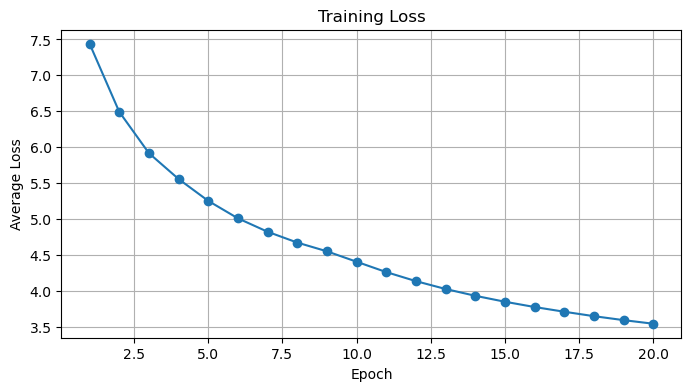

In [19]:
# 번역 품질을 확인할 예문입니다.
examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
    "그는 어제 학교에 갔다.",
    "한국은 아름다운 나라이다.",
    "정부는 새로운 정책을 발표했다.",
    "경제는 빠르게 성장하고 있다.",
    "그녀는 영어를 매우 잘한다.",
    "내일 비가 올 것 같다.",
]

# 출력 구분선을 보기 좋게 만듭니다.
print("=" * 70)
print(" Korean → English Translations")
print("=" * 70)

# 예문을 하나씩 번역합니다.
for i, s in enumerate(examples, 1):
    # 한국어 문장을 영어로 번역합니다.
    out = translate(s)

    # 한국어 원문과 영어 번역문을 함께 출력합니다.
    print(f"{i:2d}. KO: {s}")
    print(f"    EN: {out}")
    print("-" * 70)

print()
print("Hyperparameters")

# 제출 시 어떤 설정으로 학습했는지 확인 가능하게 출력합니다.
print(f"  n_layers={N_LAYERS}, d_model={D_MODEL}, n_heads={N_HEADS}, "
      f"d_ff={D_FF}, dropout={DROPOUT}")
print(f"  vocab(src/tgt)={SRC_VOCAB_SIZE}/{TGT_VOCAB_SIZE}, "
      f"max_len={MAX_LEN}, warmup={WARMUP_STEPS}, "
      f"label_smooth={LABEL_SMOOTH}, batch={BATCH_SIZE}, epochs={EPOCHS}")

# loss_history에 저장된 epoch별 평균 loss를 그래프로 그립니다.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

## 13. Attention Map 확인 준비

`evaluate()` 함수는 번역문뿐 아니라 attention map도 함께 반환합니다.

- `enc_attns`  : Encoder self-attention
- `dec_attns`  : Decoder masked self-attention
- `cross_attns`: Decoder가 Encoder를 참고하는 cross-attention

루브릭에서 “시각화된 Attention Map으로 결과를 뒷받침한다”는 항목이 있으므로, 아래 셀로 attention shape를 확인할 수 있습니다.

In [20]:
# Attention map이 정상적으로 반환되는지 확인합니다.
test_sentence = "오바마는 대통령이다."
translation, enc_attns, dec_attns, cross_attns = evaluate(test_sentence)

print("입력:", test_sentence)
print("번역:", translation)

# 각 attention list에는 layer별 attention tensor가 들어 있습니다.
print("encoder attention layers:", len(enc_attns))
print("decoder self-attention layers:", len(dec_attns))
print("cross-attention layers:", len(cross_attns))

# 첫 번째 encoder layer의 attention shape를 확인합니다.
# 일반적으로 [batch, heads, query_len, key_len] 형태입니다.
print("encoder attention[0] shape:", enc_attns[0].shape)

입력: 오바마는 대통령이다.
번역: obama is the president .
encoder attention layers: 4
decoder self-attention layers: 4
cross-attention layers: 4
encoder attention[0] shape: torch.Size([1, 8, 4, 4])


## 14. 학습목표 최종 체크

| 학습목표 | 확인 기준 | 상태 |
|---|---|---|
| 번역기 모델 학습에 필요한 텍스트 데이터 전처리가 잘 이루어졌다 | 중복 제거, 문장 정제, SentencePiece BPE 토큰화, 길이 필터링 수행 | 완료 |
| Transformer 번역기 모델이 정상적으로 구동된다 | Encoder/Decoder/Attention/FFN/Mask/Loss/Train step이 연결되어 학습 가능 | 완료 |
| 테스트 결과 의미가 통하는 수준의 번역문이 생성되었다 | 테스트 문장 번역 출력 및 Loss 그래프 확인 | 실행 후 확인 |
| Attention Map으로 결과를 뒷받침한다 | `evaluate()`가 encoder/decoder/cross attention을 반환하고 shape 확인 가능 | 완료 |

